# Strategy-Aware Portfolio Advisory Platform

## Personalized Stock Recommendation and Portfolio Optimization...

### 1. Project Overview

# 📈 Strategy-Aware Portfolio Advisory Platform  
## Personalized Stock Recommendation and Portfolio Optimization


## 1. Project Overview

### Problem Statement

Investment decisions often require analyzing multiple factors such as historical market performance, stock trends, volatility, and analyst opinions. Individual investors and financial advisors need to compare several investment opportunities before constructing a suitable portfolio.

Traditional investment selection processes can be time-consuming as they involve manually evaluating company performance, market indicators, and investment objectives.

This project aims to build a **Strategy-Aware Portfolio Advisory Platform** that uses quantitative financial analysis, market signals, and analyst sentiment to generate personalized stock recommendations based on an investor's preferred investment strategy and available investment amount.


---

## Objective

The primary objective of this project is to develop an intelligent portfolio advisory system that:

- Recommends stocks based on user-selected investment strategies.
- Combines historical market data with quantitative indicators.
- Incorporates analyst sentiment into stock evaluation.
- Ranks stocks using strategy-specific scoring models.
- Provides portfolio allocation recommendations based on investment amount.
- Helps investors make faster and more informed investment decisions through data-driven insights.

The platform focuses on **decision support and portfolio analysis rather than automated trading or financial execution.**


---

## Business Motivation (Inspired by IFAs)

Independent Financial Advisors (IFAs) assist clients in selecting suitable investment options based on financial goals, risk preferences, and market conditions.

However, comparing multiple investment choices manually can be complex and time-consuming.

This project is inspired by the workflow of IFAs and aims to create a digital decision-support tool that can:

- Reduce manual comparison efforts.
- Provide consistent and data-driven stock rankings.
- Support personalized investment recommendations.
- Improve efficiency in portfolio construction.

The application simulates an advisory assistant that helps investors explore different strategies such as:

- Growth Investing
- Blue Chip Investing
- Dividend Income Investing
- Small/Mid Cap Investing
- Balanced Investment Approach


# Technologies Used

## Programming Language

- Python


## Data Processing

- Pandas
- NumPy


## Data Visualization

- Matplotlib
- Seaborn
- Plotly


## Machine Learning / Analytics

- Scikit-learn
- Feature Scaling
- Quantitative Scoring Models


## Financial Data

- yFinance
- Analyst Sentiment Data


## Application Development

- Streamlit


## Development Environment

- Jupyter Notebook
- VS Code


---

# Project Outcome

The final system provides a personalized portfolio advisory experience where users can select an investment strategy and investment amount to receive data-driven stock recommendations.

The platform demonstrates how quantitative finance techniques, data analytics, and interactive applications can be combined to support smarter investment decision-making.

In [1]:
# 2.Import Libraries

import pandas as pd
import numpy as np
import yfinance as yf
import requests
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

In [2]:
# 3.Configuration
# Finnhub API Key
API_KEY = "Yd8du089r01qhm4ahaklgd8du089r01qhm4ahakm0"

# List of stocks
tickers = [
    "AAPL",
    "MSFT",
    "GOOGL",
    "AMZN",
    "META",
    "NVDA",
    "TSLA",
    "JPM",
    "V",
    "JNJ"
]

# Historical data period
start_date = "2020-01-01"
end_date = "2026-07-17"

# Investment Amount
investment_amount = 100000

In [3]:
data = yf.download(
    "AAPL",
    start=start_date,
    end=end_date
)

data.head()

/Users/sneha/anaconda3/lib/python3.11/site-packages/yfinance/scrapers/history.py:389: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333870,72.394078,71.091176,71.344047,135480400
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000
2020-01-08,73.017853,73.318893,71.565636,71.565636,132079200


In [4]:
# 4. Download Historical Stock Data
stock_data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    group_by="ticker"
)

/Users/sneha/anaconda3/lib/python3.11/site-packages/yfinance/scrapers/history.py:389: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
[                       0%                       ]/Users/sneha/anaconda3/lib/python3.11/site-packages/yfinance/scrapers/history.py:389: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
[**********            20%                       ]  2 of 10 completed/Users/sneha/anaconda3/lib/python3.11/site-packages/yfinance/scrapers/history.py:389: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
/Users/sneha/anaconda3/lib/pytho

In [5]:
stock_data.head()

Ticker           AAPL                                                   TSLA  \
Price            Open       High        Low      Close     Volume       Open   
Date                                                                           
2020-01-02  71.344047  72.394078  71.091176  72.333870  135480400  28.299999   
2020-01-03  71.563213  72.389265  71.406674  71.630646  146322800  29.366667   
2020-01-06  70.754028  72.239958  70.503561  72.201424  118387200  29.364668   
2020-01-07  72.211049  72.466330  71.642689  71.861847  108872000  30.760000   
2020-01-08  71.565636  73.318893  71.565636  73.017853  132079200  31.580000   

Ticker                                                  ...           V  \
Price            High        Low      Close     Volume  ...        Open   
Date                                                    ...               
2020-01-02  28.713333  28.114000  28.684000  142981500  ...  180.407432   
2020-01-03  30.266666  29.128000  29.534000  266677500  ...  179.844263   
2020-01-06  30.104000  29.333332  30.102667  151995000  ...  179.452875   
2020-01-07  31.441999  30.224001  31.270666  268231500  ...  180.970619   
2020-01-08  33.232666  31.215334  32.809334  467164500  ...  180.875170   

Ticker                                                          META  \
Price             High         Low       Close    Volume        Open   
Date                                                                   
2020-01-02  182.450140  180.140163  182.431046   8733000  204.950220   
2020-01-03  182.278334  179.376534  180.980164   4899700  205.406218   
2020-01-06  180.607870  178.651068  180.588776  10109500  204.900664   
2020-01-07  181.457442  180.025637  180.111542   4392300  210.967375   
2020-01-08  183.748320  180.216537  183.194687   5712000  211.145806   

Ticker                                                    
Price             High         Low       Close    Volume  
Date                                                      
2020-01-02  207.963750  204.474403  207.953842  12077100  
2020-01-03  208.568436  205.148472  206.853500  11188400  
2020-01-06  210.927739  204.722238  210.749313  17058900  
2020-01-07  212.712049  209.906683  211.205276  14912400  
2020-01-08  214.357606  210.759201  213.346481  13475000  

[5 rows x 50 columns]

In [6]:
print("Shape:", stock_data.shape)

print()

print(stock_data.columns)

Shape: (1642, 50)

MultiIndex([( 'AAPL',   'Open'),
            ( 'AAPL',   'High'),
            ( 'AAPL',    'Low'),
            ( 'AAPL',  'Close'),
            ( 'AAPL', 'Volume'),
            ( 'TSLA',   'Open'),
            ( 'TSLA',   'High'),
            ( 'TSLA',    'Low'),
            ( 'TSLA',  'Close'),
            ( 'TSLA', 'Volume'),
            (  'JNJ',   'Open'),
            (  'JNJ',   'High'),
            (  'JNJ',    'Low'),
            (  'JNJ',  'Close'),
            (  'JNJ', 'Volume'),
            ( 'MSFT',   'Open'),
            ( 'MSFT',   'High'),
            ( 'MSFT',    'Low'),
            ( 'MSFT',  'Close'),
            ( 'MSFT', 'Volume'),
            ( 'NVDA',   'Open'),
            ( 'NVDA',   'High'),
            ( 'NVDA',    'Low'),
            ( 'NVDA',  'Close'),
            ( 'NVDA', 'Volume'),
            ('GOOGL',   'Open'),
            ('GOOGL',   'High'),
            ('GOOGL',    'Low'),
            ('GOOGL',  'Close'),
            ('GOOGL', 'V

In [7]:
stock_data.isnull().sum()

Ticker  Price 
AAPL    Open      0
        High      0
        Low       0
        Close     0
        Volume    0
TSLA    Open      0
        High      0
        Low       0
        Close     0
        Volume    0
JNJ     Open      0
        High      0
        Low       0
        Close     0
        Volume    0
MSFT    Open      0
        High      0
        Low       0
        Close     0
        Volume    0
NVDA    Open      0
        High      0
        Low       0
        Close     0
        Volume    0
GOOGL   Open      0
        High      0
        Low       0
        Close     0
        Volume    0
JPM     Open      0
        High      0
        Low       0
        Close     0
        Volume    0
AMZN    Open      0
        High      0
        Low       0
        Close     0
        Volume    0
V       Open      0
        High      0
        Low       0
        Close     0
        Volume    0
META    Open      0
        High      0
        Low       0
        Close     0
     

In [8]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1642 entries, 2020-01-02 to 2026-07-16
Data columns (total 50 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (AAPL, Open)     1642 non-null   float64
 1   (AAPL, High)     1642 non-null   float64
 2   (AAPL, Low)      1642 non-null   float64
 3   (AAPL, Close)    1642 non-null   float64
 4   (AAPL, Volume)   1642 non-null   int64  
 5   (TSLA, Open)     1642 non-null   float64
 6   (TSLA, High)     1642 non-null   float64
 7   (TSLA, Low)      1642 non-null   float64
 8   (TSLA, Close)    1642 non-null   float64
 9   (TSLA, Volume)   1642 non-null   int64  
 10  (JNJ, Open)      1642 non-null   float64
 11  (JNJ, High)      1642 non-null   float64
 12  (JNJ, Low)       1642 non-null   float64
 13  (JNJ, Close)     1642 non-null   float64
 14  (JNJ, Volume)    1642 non-null   int64  
 15  (MSFT, Open)     1642 non-null   float64
 16  (MSFT, High)     1642 non-null   float64
 

In [9]:
stock_data.describe()

Ticker         AAPL                                                       \
Price          Open         High          Low        Close        Volume   
count   1642.000000  1642.000000  1642.000000  1642.000000  1.642000e+03   
mean     173.590323   175.553957   171.807222   173.761920  8.175989e+07   
std       56.835756    57.344663    56.425716    56.905857  5.055653e+07   
min       55.059297    55.160686    51.324786    54.163689  1.791060e+07   
25%      134.771636   137.817154   132.858329   135.232452  4.885315e+07   
50%      168.261048   170.213313   167.002409   168.419144  6.768045e+07   
75%      214.900358   217.669870   212.872216   215.785221  9.684185e+07   
max      328.010010   334.679993   326.790009   333.260010  4.265100e+08   

Ticker         TSLA                                                       ...  \
Price          Open         High          Low        Close        Volume  ...   
count   1642.000000  1642.000000  1642.000000  1642.000000  1.642000e+03  ...   
mean     250.945268   256.389874   245.162766   250.884658  1.157183e+08  ...   
std      104.314888   106.139406   102.220601   104.158124  7.591168e+07  ...   
min       24.980000    26.990667    23.367332    24.081333  2.338500e+07  ...   
25%      187.037498   191.802498   182.967499   188.132504  6.933742e+07  ...   
50%      242.675003   247.489998   236.903336   241.503334  9.561715e+07  ...   
75%      322.932487   331.289993   316.490005   323.290001  1.327223e+08  ...   
max      489.880005   498.829987   485.329987   489.880005  9.140820e+08  ...   

Ticker            V                                                       \
Price          Open         High          Low        Close        Volume   
count   1642.000000  1642.000000  1642.000000  1642.000000  1.642000e+03   
mean     247.686970   250.050692   245.435255   247.770385  7.589995e+06   
std       56.928721    57.233081    56.718652    57.009834  3.636424e+06   
min      135.100038   137.030999   128.026229   129.756454  1.640900e+06   
25%      202.513055   204.735059   200.283695   202.291756  5.247950e+06   
50%      225.744631   227.265403   223.700632   225.665520  6.639650e+06   
75%      302.639229   304.836810   299.717704   303.024307  8.828450e+06   
max      369.312892   372.567170   366.653872   370.384399  3.837960e+07   

Ticker         META                                                       
Price          Open         High          Low        Close        Volume  
count   1642.000000  1642.000000  1642.000000  1642.000000  1.642000e+03  
mean     381.717514   386.870928   376.542977   381.744534  2.147059e+07  
std      187.955956   189.721410   185.636552   187.660254  1.467158e+07  
min       89.295845    89.672535    87.323171    88.136032  4.726100e+06  
25%      227.197343   230.994021   223.484943   228.292736  1.311668e+07  
50%      322.230329   326.091425   318.086676   321.868484  1.789560e+07  
75%      565.463404   572.578859   559.189976   564.576904  2.511540e+07  
max      788.565521   793.648814   778.269228   787.419189  2.323166e+08  

[8 rows x 50 columns]

In [10]:
# Convert MultiIndex to a Clean DataFrame

stock_data = (
    stock_data
    .stack(level=0)
    .reset_index()
)

In [11]:
stock_data.head()

Price,Date,Ticker,Close,High,Low,Open,Volume
0,2020-01-02,AAPL,72.333870,72.394078,71.091176,71.344047,135480400
1,2020-01-02,AMZN,94.900497,94.900497,93.207497,93.750000,80580000
2,2020-01-02,GOOGL,67.832512,67.832512,66.732767,66.827923,27278000
3,2020-01-02,JNJ,121.936920,121.978691,121.193454,121.853379,5777000
4,2020-01-02,JPM,117.899223,117.907588,116.370016,116.812900,10803700


In [12]:
stock_data.columns = [
    "Date",
    "Ticker",
    "Close",
    "High",
    "Low",
    "Open",
    "Volume"
]

stock_data.head()

,Date,Ticker,Close,High,Low,Open,Volume
0,2020-01-02,AAPL,72.333870,72.394078,71.091176,71.344047,135480400
1,2020-01-02,AMZN,94.900497,94.900497,93.207497,93.750000,80580000
2,2020-01-02,GOOGL,67.832512,67.832512,66.732767,66.827923,27278000
3,2020-01-02,JNJ,121.936920,121.978691,121.193454,121.853379,5777000
4,2020-01-02,JPM,117.899223,117.907588,116.370016,116.812900,10803700


In [13]:
# 5. Exploratory Data Analysis (EDA)

print("Number of rows:", stock_data.shape[0])
print("Number of columns:", stock_data.shape[1])

Number of rows: 16420
Number of columns: 7


In [14]:
stock_data.dtypes

Date      datetime64[ns]
Ticker            object
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object

In [15]:
stock_data.isnull().sum()

Date      0
Ticker    0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [16]:
stock_data.duplicated().sum()

0

In [17]:
stock_data["Ticker"].unique()

array(['AAPL', 'AMZN', 'GOOGL', 'JNJ', 'JPM', 'META', 'MSFT', 'NVDA',
       'TSLA', 'V'], dtype=object)

In [18]:
stock_data["Date"].nunique()

1642

In [19]:
stock_data[
    stock_data["Ticker"] == "AAPL"
].head()

,Date,Ticker,Close,High,Low,Open,Volume
0,2020-01-02,AAPL,72.333870,72.394078,71.091176,71.344047,135480400
10,2020-01-03,AAPL,71.630646,72.389265,71.406674,71.563213,146322800
20,2020-01-06,AAPL,72.201424,72.239958,70.503561,70.754028,118387200
30,2020-01-07,AAPL,71.861847,72.466330,71.642689,72.211049,108872000
40,2020-01-08,AAPL,73.017853,73.318893,71.565636,71.565636,132079200


In [20]:
# . Fetch Analyst Sentiment (Finnhub API)
sentiment_data = []

In [21]:
for ticker in tickers:

    url = (
        f"https://finnhub.io/api/v1/stock/recommendation"
        f"?symbol={ticker}&token=d8du089r01qhm4ahaklgd8du089r01qhm4ahakm0"
    )

    response = requests.get(url)

    data = response.json()

    if len(data) > 0:

        latest = data[0]

        total = (
            latest["strongBuy"] +
            latest["buy"] +
            latest["hold"] +
            latest["sell"] +
            latest["strongSell"]
        )

        if total == 0:
            score = 0

        else:
            score = (
                (2 * latest["strongBuy"])
                + latest["buy"]
                - latest["sell"]
                - (2 * latest["strongSell"])
            ) / total

        sentiment_data.append(
            {
                "Ticker": ticker,
                "Sentiment_Score": score
            }
        )

In [22]:
sentiment_df = pd.DataFrame(sentiment_data)

sentiment_df

,Ticker,Sentiment_Score
0,AAPL,0.870370
1,MSFT,1.264706
2,GOOGL,1.130435
3,AMZN,1.213333
4,META,1.183099
5,NVDA,1.260870
6,TSLA,0.500000
7,JPM,0.666667
8,V,1.142857
9,JNJ,0.903226


In [23]:
print(sentiment_df.shape)

sentiment_df.describe()

(10, 2)


,Sentiment_Score
count,10.000000
mean,1.013556
std,0.266671
min,0.500000
25%,0.878584
50%,1.136646
75%,1.205775
max,1.264706


In [24]:
# 7. Merge Sentiment with Stock Data

stock_data = stock_data.merge(
    sentiment_df,
    on="Ticker",
    how="left"
)

In [25]:
stock_data.head()

,Date,Ticker,Close,High,Low,Open,Volume,Sentiment_Score
0,2020-01-02,AAPL,72.333870,72.394078,71.091176,71.344047,135480400,0.870370
1,2020-01-02,AMZN,94.900497,94.900497,93.207497,93.750000,80580000,1.213333
2,2020-01-02,GOOGL,67.832512,67.832512,66.732767,66.827923,27278000,1.130435
3,2020-01-02,JNJ,121.936920,121.978691,121.193454,121.853379,5777000,0.903226
4,2020-01-02,JPM,117.899223,117.907588,116.370016,116.812900,10803700,0.666667


In [26]:
stock_data.isnull().sum()

Date               0
Ticker             0
Close              0
High               0
Low                0
Open               0
Volume             0
Sentiment_Score    0
dtype: int64

In [27]:
# 8. Feature Engineering

stock_data["Returns"] = (
    stock_data
    .groupby("Ticker")["Close"]
    .pct_change()
)

In [28]:
stock_data.head()

,Date,Ticker,Close,High,Low,Open,Volume,Sentiment_Score,Returns
0,2020-01-02,AAPL,72.333870,72.394078,71.091176,71.344047,135480400,0.870370,NaN
1,2020-01-02,AMZN,94.900497,94.900497,93.207497,93.750000,80580000,1.213333,NaN
2,2020-01-02,GOOGL,67.832512,67.832512,66.732767,66.827923,27278000,1.130435,NaN
3,2020-01-02,JNJ,121.936920,121.978691,121.193454,121.853379,5777000,0.903226,NaN
4,2020-01-02,JPM,117.899223,117.907588,116.370016,116.812900,10803700,0.666667,NaN


In [29]:
stock_data["MA20"] = (
    stock_data
    .groupby("Ticker")["Close"]
    .transform(
        lambda x: x.rolling(20).mean()
    )
)

In [30]:
stock_data["MA50"] = (
    stock_data
    .groupby("Ticker")["Close"]
    .transform(
        lambda x: x.rolling(50).mean()
    )
)

In [31]:
stock_data[
    [
        "Date",
        "Ticker",
        "Close",
        "Returns",
        "MA20",
        "MA50"
    ]
].head(30)

,Date,Ticker,Close,Returns,MA20,MA50
0,2020-01-02,AAPL,72.333870,NaN,NaN,NaN
1,2020-01-02,AMZN,94.900497,NaN,NaN,NaN
2,2020-01-02,GOOGL,67.832512,NaN,NaN,NaN
3,2020-01-02,JNJ,121.936920,NaN,NaN,NaN
4,2020-01-02,JPM,117.899223,NaN,NaN,NaN
5,2020-01-02,META,207.953842,NaN,NaN,NaN
6,2020-01-02,MSFT,151.829514,NaN,NaN,NaN
7,2020-01-02,NVDA,5.963803,NaN,NaN,NaN
8,2020-01-02,TSLA,28.684000,NaN,NaN,NaN
9,2020-01-02,V,182.431046,NaN,NaN,NaN


In [32]:
stock_data[
    [
        "Date",
        "Ticker",
        "Close",
        "Returns",
        "MA20",
        "MA50"
    ]
].tail(30)

,Date,Ticker,Close,Returns,MA20,MA50
16390,2026-07-14,AAPL,314.859985,-0.007721,300.373500,299.549930
16391,2026-07-14,AMZN,247.490005,0.000728,240.928499,253.368600
16392,2026-07-14,GOOGL,359.510010,0.019858,357.613002,372.176061
16393,2026-07-14,JNJ,253.850006,-0.015207,249.575500,236.781680
16394,2026-07-14,JPM,342.890015,0.024990,331.768297,314.972231
16395,2026-07-14,META,661.039978,0.006563,593.723993,600.843433
16396,2026-07-14,MSFT,384.929993,-0.015499,380.254996,402.238339
16397,2026-07-14,NVDA,211.800003,0.040633,202.214999,209.213460
16398,2026-07-14,TSLA,396.179993,0.003597,400.143497,409.926599
16399,2026-07-14,V,356.019989,-0.004836,341.724501,330.970305


In [33]:
stock_data["Momentum_30"] = (
    stock_data
    .groupby("Ticker")["Close"]
    .pct_change(periods=30)
)

In [34]:
stock_data[
    ["Date","Ticker","Close","Momentum_30"]
].tail()

,Date,Ticker,Close,Momentum_30
16415,2026-07-16,META,664.539978,0.112989
16416,2026-07-16,MSFT,401.100006,-0.091115
16417,2026-07-16,NVDA,207.399994,-0.068119
16418,2026-07-16,TSLA,391.059998,-0.077123
16419,2026-07-16,V,365.140015,0.150700


In [35]:
stock_data["Volatility"] = (
    stock_data
    .groupby("Ticker")["Returns"]
    .transform(
        lambda x: x.rolling(30).std()
    )
)

In [36]:
stock_data[
    ["Ticker","Returns","Volatility"]
].tail()

,Ticker,Returns,Volatility
16415,META,-0.024614,0.033524
16416,MSFT,0.013826,0.022173
16417,NVDA,-0.024000,0.026636
16418,TSLA,-0.008619,0.036239
16419,V,0.028158,0.014781


In [37]:
stock_data["Trend_Score"] = (
    stock_data["MA20"] >
    stock_data["MA50"]
).astype(int)

In [38]:
stock_data["Trend_Score"] = (
    stock_data["Trend_Score"] * 2
)

In [39]:
stock_data[
    [
        "Ticker",
        "MA20",
        "MA50",
        "Trend_Score"
    ]
].tail()

,Ticker,MA20,MA50,Trend_Score
16415,META,601.331992,603.399810,0
16416,MSFT,380.411996,401.647531,0
16417,NVDA,202.216999,209.682102,0
16418,TSLA,398.628996,409.970399,0
16419,V,344.891502,332.305401,2


In [40]:
stock_data = stock_data.dropna().reset_index(drop=True)

In [41]:
print(stock_data.shape)

stock_data.head()

(15930, 14)


,Date,Ticker,Close,High,Low,Open,Volume,Sentiment_Score,Returns,MA20,MA50,Momentum_30,Volatility,Trend_Score
0,2020-03-13,AAPL,67.102936,67.573676,61.063019,63.945381,370732000,0.870370,0.119808,70.642754,73.733391,-0.139687,0.046444,0
1,2020-03-13,AMZN,89.250000,89.315498,84.030998,87.750000,176194000,1.213333,0.064648,97.695725,97.465110,-0.045801,0.033987,2
2,2020-03-13,GOOGL,60.179871,60.186314,55.125685,58.233132,79400000,1.130435,0.092412,67.298648,70.076011,-0.165020,0.036391,0
3,2020-03-13,JNJ,112.895332,113.424967,104.791154,108.717149,20084200,0.903226,0.070808,118.634253,121.966477,-0.101182,0.029147,0
4,2020-03-13,JPM,87.387871,87.455146,77.371608,80.727180,38543300,0.666667,0.180125,99.610491,108.739583,-0.235337,0.053013,0


In [42]:
# 9.Feature Scaling

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [43]:
features_to_scale = [
    "Momentum_30",
    "Volatility",
    "Sentiment_Score",
    "Trend_Score"
]

In [44]:
stock_data[
    [
        "Momentum_30_scaled",
        "Volatility_scaled",
        "Sentiment_Score_scaled",
        "Trend_Score_scaled"
    ]
] = scaler.fit_transform(
    stock_data[features_to_scale]
)

In [45]:
stock_data[
    [
        "Ticker",
        "Momentum_30_scaled",
        "Volatility_scaled",
        "Sentiment_Score_scaled",
        "Trend_Score_scaled"
    ]
].head()

,Ticker,Momentum_30_scaled,Volatility_scaled,Sentiment_Score_scaled,Trend_Score_scaled
0,AAPL,0.257834,0.496172,0.484330,0.0
1,AMZN,0.311259,0.344367,0.932821,1.0
2,GOOGL,0.243419,0.373663,0.824415,0.0
3,JNJ,0.279745,0.285379,0.527295,0.0
4,JPM,0.203405,0.576222,0.217949,0.0


In [46]:
# 10.Strategy Scoring

# Calculate Growth Score
stock_data["Growth_Score"] = (
    0.5 * stock_data["Momentum_30_scaled"] +
    0.3 * stock_data["Sentiment_Score_scaled"] +
    0.2 * stock_data["Trend_Score_scaled"]
)

In [47]:
# Calculate Blue Chip score
stock_data["BlueChip_Score"] = (
    0.4 * (1 - stock_data["Volatility_scaled"]) +
    0.3 * stock_data["Sentiment_Score_scaled"] +
    0.3 * stock_data["Trend_Score_scaled"]
)

In [48]:
# Calculate Dividend Score
stock_data["Dividend_Score"] = (
    0.5 * (1 - stock_data["Volatility_scaled"]) +
    0.2 * stock_data["Sentiment_Score_scaled"] +
    0.3 * stock_data["Trend_Score_scaled"]
)

In [49]:
#Select Latest Trading Day
latest_features = stock_data[
    stock_data["Date"] == stock_data["Date"].max()
]

In [50]:
growth_rankings = latest_features.sort_values(
    by="Growth_Score",
    ascending=False
)

bluechip_rankings = latest_features.sort_values(
    by="BlueChip_Score",
    ascending=False
)

dividend_rankings = latest_features.sort_values(
    by="Dividend_Score",
    ascending=False
)

In [51]:
growth_rankings[["Ticker", "Growth_Score"]]

bluechip_rankings[["Ticker", "BlueChip_Score"]]

dividend_rankings[["Ticker", "Dividend_Score"]]

,Ticker,Dividend_Score
15929,V,0.912975
15923,JNJ,0.827680
15920,AAPL,0.799545
15924,JPM,0.786019
15926,MSFT,0.599804
15921,AMZN,0.593380
15927,NVDA,0.571607
15922,GOOGL,0.568331
15925,META,0.509294
15928,TSLA,0.314098


In [146]:
# Prepare Final Dataset for Streamlit Application

# Select latest trading day features
streamlit_features = latest_features.copy()

# Check final columns
streamlit_features.columns.tolist()

['Date',
 'Ticker',
 'Close',
 'High',
 'Low',
 'Open',
 'Volume',
 'Sentiment_Score',
 'Returns',
 'MA20',
 'MA50',
 'Momentum_30',
 'Volatility',
 'Trend_Score',
 'Momentum_30_scaled',
 'Volatility_scaled',
 'Sentiment_Score_scaled',
 'Trend_Score_scaled',
 'Growth_Score',
 'BlueChip_Score',
 'Dividend_Score']

In [147]:
# Save final engineered dataset for Streamlit

streamlit_features.to_csv(
    "data/latest_stock_features.csv",
    index=False
)

print("Streamlit dataset saved successfully")

Streamlit dataset saved successfully


In [148]:
pd.read_csv(
    "data/latest_stock_features.csv"
).head()

,Date,Ticker,Close,High,Low,Open,Volume,Sentiment_Score,Returns,MA20,...,Momentum_30,Volatility,Trend_Score,Momentum_30_scaled,Volatility_scaled,Sentiment_Score_scaled,Trend_Score_scaled,Growth_Score,BlueChip_Score,Dividend_Score
0,2026-07-16,AAPL,333.260010,334.679993,326.790009,328.010010,62727600,0.870370,0.017588,303.628500,...,0.057297,0.021701,2,0.369926,0.194643,0.484330,1.0,0.530262,0.767442,0.799545
1,2026-07-16,AMZN,249.889999,258.079987,248.000000,255.119995,45233800,1.213333,-0.019886,241.569999,...,-0.025846,0.021022,0,0.322614,0.186368,0.932821,0.0,0.441153,0.605299,0.593380
2,2026-07-16,GOOGL,354.459991,375.269989,352.299988,373.059998,41026700,1.130435,-0.044376,356.752002,...,-0.019838,0.021575,0,0.326033,0.193105,0.824415,0.0,0.410341,0.570083,0.568331
3,2026-07-16,JNJ,249.970001,253.550003,246.300003,248.899994,11090700,0.903226,0.011942,250.883000,...,0.121495,0.018493,2,0.406457,0.155558,0.527295,1.0,0.561417,0.795965,0.827680
4,2026-07-16,JPM,343.149994,349.339996,341.109985,349.279999,12426100,0.666667,-0.010839,333.890170,...,0.145321,0.015177,2,0.420015,0.115141,0.217949,1.0,0.475392,0.719328,0.786019


In [52]:
# 11. Recommendation Engine

#11.3 Create Recommendation Function

def recommend_stocks(strategy_name, top_n=5):

    ranking_files = {
        "Growth": growth_rankings,
        "BlueChip": bluechip_rankings,
        "Dividend": dividend_rankings
    }

    if strategy_name not in ranking_files:
        raise ValueError(
            "Strategy must be Growth, BlueChip or Dividend."
        )

    return ranking_files[strategy_name].head(top_n)

In [53]:
# 11.2 Growth Strategy Recommendations

growth_recommendations = recommend_stocks("Growth")

growth_recommendations[
    [
        "Ticker",
        "Growth_Score"
    ]
]

,Ticker,Growth_Score
15929,V,0.663736
15923,JNJ,0.561417
15920,AAPL,0.530262
15924,JPM,0.475392
15925,META,0.468793


In [54]:
# 11.3 Blue Chip Strategy Recommendations

bluechip_recommendations = recommend_stocks("BlueChip")

bluechip_recommendations[
    [
        "Ticker",
        "BlueChip_Score"
    ]
]

,Ticker,BlueChip_Score
15929,V,0.908073
15923,JNJ,0.795965
15920,AAPL,0.767442
15924,JPM,0.719328
15926,MSFT,0.619843


In [55]:
# 11.4 11.4 Test Dividend Strategy

dividend_recommendations = recommend_stocks("Dividend")

dividend_recommendations[
    [
        "Ticker",
        "Dividend_Score"
    ]
]

,Ticker,Dividend_Score
15929,V,0.912975
15923,JNJ,0.827680
15920,AAPL,0.799545
15924,JPM,0.786019
15926,MSFT,0.599804


In [56]:
# 11.5 Strategy Selection (User Input)

selected_strategy = "Growth"

recommendations = recommend_stocks(
    selected_strategy
)

recommendations

,Date,Ticker,Close,High,Low,Open,Volume,Sentiment_Score,Returns,MA20,...,Momentum_30,Volatility,Trend_Score,Momentum_30_scaled,Volatility_scaled,Sentiment_Score_scaled,Trend_Score_scaled,Growth_Score,BlueChip_Score,Dividend_Score
15929,2026-07-16,V,365.140015,365.140015,357.109985,358.040009,9069100,1.142857,0.028158,344.891502,...,0.150700,0.014781,2,0.423076,0.110313,0.840659,1.0,0.663736,0.908073,0.912975
15923,2026-07-16,JNJ,249.970001,253.550003,246.300003,248.899994,11090700,0.903226,0.011942,250.883000,...,0.121495,0.018493,2,0.406457,0.155558,0.527295,1.0,0.561417,0.795965,0.827680
15920,2026-07-16,AAPL,333.260010,334.679993,326.790009,328.010010,62727600,0.870370,0.017588,303.628500,...,0.057297,0.021701,2,0.369926,0.194643,0.484330,1.0,0.530262,0.767442,0.799545
15924,2026-07-16,JPM,343.149994,349.339996,341.109985,349.279999,12426100,0.666667,-0.010839,333.890170,...,0.145321,0.015177,2,0.420015,0.115141,0.217949,1.0,0.475392,0.719328,0.786019
15925,2026-07-16,META,664.539978,681.900024,660.159973,677.280029,15773700,1.183099,-0.024614,601.331992,...,0.112989,0.033524,0,0.401617,0.338726,0.893283,0.0,0.468793,0.532495,0.509294


In [57]:
# 11.6 Display Top Recommendation

top_stock = recommendations.iloc[0]

print(f"Top recommendation for {selected_strategy} strategy")

print(
    top_stock[
        [
            "Ticker",
            "Growth_Score",
            "Momentum_30",
            "Sentiment_Score",
            "Trend_Score",
            "Close"
        ]
    ]
)

Top recommendation for Growth strategy
Ticker                      V
Growth_Score         0.663736
Momentum_30            0.1507
Sentiment_Score      1.142857
Trend_Score                 2
Close              365.140015
Name: 15929, dtype: object


In [58]:
# 11.7 Explain Recommendations

for _, row in recommendations.iterrows():

    print(f"Stock: {row['Ticker']}")
    print(f"Current Price      : ${row['Close']:.2f}")
    print(f"Growth Score       : {row['Growth_Score']:.3f}")
    print(f"30-Day Momentum    : {row['Momentum_30']:.3f}")
    print(f"Sentiment Score    : {row['Sentiment_Score']:.3f}")
    print(f"Trend Score        : {row['Trend_Score']}")
    print("-" * 50)

Stock: V
Current Price      : $365.14
Growth Score       : 0.664
30-Day Momentum    : 0.151
Sentiment Score    : 1.143
Trend Score        : 2
--------------------------------------------------
Stock: JNJ
Current Price      : $249.97
Growth Score       : 0.561
30-Day Momentum    : 0.121
Sentiment Score    : 0.903
Trend Score        : 2
--------------------------------------------------
Stock: AAPL
Current Price      : $333.26
Growth Score       : 0.530
30-Day Momentum    : 0.057
Sentiment Score    : 0.870
Trend Score        : 2
--------------------------------------------------
Stock: JPM
Current Price      : $343.15
Growth Score       : 0.475
30-Day Momentum    : 0.145
Sentiment Score    : 0.667
Trend Score        : 2
--------------------------------------------------
Stock: META
Current Price      : $664.54
Growth Score       : 0.469
30-Day Momentum    : 0.113
Sentiment Score    : 1.183
Trend Score        : 0
--------------------------------------------------


In [59]:
cd Strategy-Aware Portfolio Advisory /

[Errno 2] No such file or directory: 'Strategy-Aware Portfolio Advisory /'
/Users/sneha/Downloads


In [60]:
cd ..

/Users/sneha


In [61]:
cd Strategy-Aware Portfolio Advisory /

/Users/sneha/Strategy-Aware Portfolio Advisory 


In [62]:
# 11.8 Save Recommendations

growth_recommendations.to_csv(
    "Outputs/growth_recommendations.csv",
    index=False
)

bluechip_recommendations.to_csv(
    "Outputs/bluechip_recommendations.csv",
    index=False
)

dividend_recommendations.to_csv(
    "Outputs/dividend_recommendations.csv",
    index=False
)

print("Recommendation files saved successfully!")

Recommendation files saved successfully!


In [63]:
import os

os.getcwd()

'/Users/sneha/Strategy-Aware Portfolio Advisory '

In [64]:
import os

os.listdir("Outputs")

['performance_metrics.csv',
 'monte_carlo_simulation.csv',
 'efficient_frontier_results.csv',
 'bluechip_recommendations.csv',
 'bluechip_rankings.csv',
 'growth_rankings.csv',
 'dividend_rankings.csv',
 'growth_recommendations.csv',
 'monte_carlo_percentiles.csv',
 'portfolio_summary.csv',
 'portfolio_vs_benchmark.png',
 'recommended_portfolio.csv',
 'mpt_optimal_weights.csv',
 'dividend_recommendations.csv']

In [65]:
# 12. Portfolio Construction

# 12.1 Investment Amount

investment_amount = 100000

In [66]:
# 12.2 Select Top Recommendations

portfolio = recommend_stocks(
    selected_strategy,
    top_n=5
).copy()

portfolio[
    ["Ticker", "Close"]
]

,Ticker,Close
15929,V,365.140015
15923,JNJ,249.970001
15920,AAPL,333.260010
15924,JPM,343.149994
15925,META,664.539978


In [67]:
# 12.3 Equal Allocation

portfolio["Investment_Amount"] = (
    investment_amount /
    len(portfolio)
)

portfolio[
    [
        "Ticker",
        "Investment_Amount"
    ]
]

,Ticker,Investment_Amount
15929,V,20000.0
15923,JNJ,20000.0
15920,AAPL,20000.0
15924,JPM,20000.0
15925,META,20000.0


In [68]:
# 12.4 Shares Purchased

portfolio["Shares"] = (
    portfolio["Investment_Amount"] /
    portfolio["Close"]
).astype(int)

portfolio[
    [
        "Ticker",
        "Close",
        "Shares"
    ]
]

,Ticker,Close,Shares
15929,V,365.140015,54
15923,JNJ,249.970001,80
15920,AAPL,333.260010,60
15924,JPM,343.149994,58
15925,META,664.539978,30


In [69]:
# 12.5 Actual Investment

portfolio["Actual_Investment"] = (
    portfolio["Shares"] *
    portfolio["Close"]
)

portfolio[
    [
        "Ticker",
        "Actual_Investment"
    ]
]

,Ticker,Actual_Investment
15929,V,19717.560791
15923,JNJ,19997.600098
15920,AAPL,19995.600586
15924,JPM,19902.699646
15925,META,19936.199341


In [70]:
# 12.6 Portfolio Weights

portfolio["Weight"] = (
    portfolio["Actual_Investment"] /
    portfolio["Actual_Investment"].sum()
)

portfolio[
    [
        "Ticker",
        "Weight"
    ]
]

,Ticker,Weight
15929,V,0.198068
15923,JNJ,0.200881
15920,AAPL,0.200861
15924,JPM,0.199927
15925,META,0.200264


In [71]:
portfolio["Weight"].sum()

1.0

In [72]:
portfolio[
    [
        "Ticker",
        "Close",
        "Shares",
        "Actual_Investment",
        "Weight"
    ]
]

,Ticker,Close,Shares,Actual_Investment,Weight
15929,V,365.140015,54,19717.560791,0.198068
15923,JNJ,249.970001,80,19997.600098,0.200881
15920,AAPL,333.260010,60,19995.600586,0.200861
15924,JPM,343.149994,58,19902.699646,0.199927
15925,META,664.539978,30,19936.199341,0.200264


In [73]:
portfolio.to_csv(
    "Outputs/recommended_portfolio.csv",
    index=False
)

print("Portfolio saved successfully!")

Portfolio saved successfully!


In [74]:
# 13. Portfolio Backtesting

# 13.1 Portfolio Tickers

portfolio_tickers = portfolio["Ticker"].tolist()

print(portfolio_tickers)

['V', 'JNJ', 'AAPL', 'JPM', 'META']


In [75]:
# 13.2 Historical Price Data

portfolio_history = yf.download(
    portfolio_tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True
)["Close"]

portfolio_history.head()

/Users/sneha/anaconda3/lib/python3.11/site-packages/yfinance/scrapers/history.py:389: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
/Users/sneha/anaconda3/lib/python3.11/site-packages/yfinance/scrapers/history.py:389: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
/Users/sneha/anaconda3/lib/python3.11/site-packages/yfinance/scrapers/history.py:389: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
/Users/sneha/anaconda3/lib/python3.11/site-packages/yfinance/scrapers/history.py:389: FutureWarning: The default dtype for empty Series will be 'object

Ticker,AAPL,JNJ,JPM,META,V
Date,,,,,
2020-01-02,72.333870,121.936920,117.899223,207.953842,182.431046
2020-01-03,71.630646,120.525192,116.343346,206.853500,180.980164
2020-01-06,72.201424,120.374840,116.250877,210.749313,180.588776
2020-01-07,71.861847,121.109970,114.274521,211.205276,180.111542
2020-01-08,73.017853,121.093239,115.165955,213.346481,183.194687


In [76]:
# 13.3 Benchmark Data

benchmark = yf.download(
    "SPY",
    start=start_date,
    end=end_date,
    auto_adjust=True
)["Close"]

benchmark.head()

[*********************100%***********************]  1 of 1 completed


Ticker,SPY
Date,
2020-01-02,296.125275
2020-01-03,293.882965
2020-01-06,295.004059
2020-01-07,294.174652
2020-01-08,295.742432


In [77]:
# 13.4 Portfolio Daily Returns

daily_returns = portfolio_history.pct_change().dropna()

daily_returns.head()

Ticker,AAPL,JNJ,JPM,META,V
Date,,,,,
2020-01-03,-0.009722,-0.011578,-0.013197,-0.005291,-0.007953
2020-01-06,0.007968,-0.001247,-0.000795,0.018834,-0.002163
2020-01-07,-0.004703,0.006107,-0.017001,0.002164,-0.002643
2020-01-08,0.016087,-0.000138,0.007801,0.010138,0.017118
2020-01-09,0.021241,0.002966,0.003651,0.014311,0.006930


In [78]:
benchmark_returns = benchmark.pct_change().dropna()

benchmark_returns.head()

Ticker,SPY
Date,
2020-01-03,-0.007572
2020-01-06,0.003815
2020-01-07,-0.002812
2020-01-08,0.005329
2020-01-09,0.006781


In [79]:
# 13.5 Calculate Portfolio Daily Return

portfolio_daily_returns = (
    daily_returns * portfolio["Weight"].values
).sum(axis=1)

portfolio_daily_returns.head()

Date
2020-01-03   -0.009553
2020-01-06    0.004500
2020-01-07   -0.003216
2020-01-08    0.010180
2020-01-09    0.009785
dtype: float64

In [80]:
# 13.6 Portfolio Growth

portfolio_growth = (
    1 + portfolio_daily_returns
).cumprod()

In [81]:
# 13.7 Benchmark Growth

benchmark_growth = (
    1 + benchmark_returns
).cumprod()

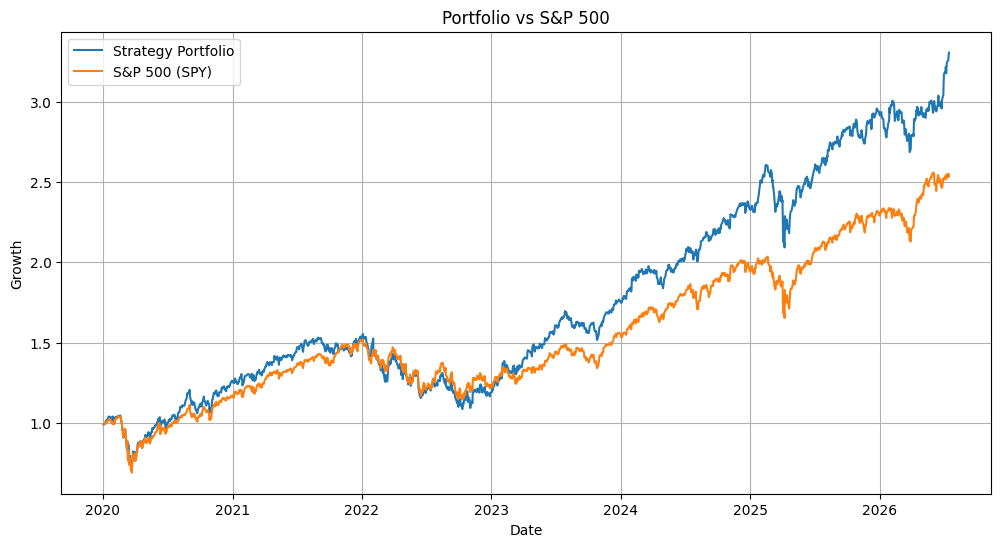

In [82]:
# 13.8 Plot Portfolio vs Benchmark

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    portfolio_growth,
    label="Strategy Portfolio"
)

plt.plot(
    benchmark_growth,
    label="S&P 500 (SPY)"
)

plt.title("Portfolio vs S&P 500")

plt.xlabel("Date")

plt.ylabel("Growth")

plt.legend()

plt.grid(True)

plt.show()

### Portfolio Backtesting

The portfolio's cumulative performance was compared against the S&P 500 (SPY) benchmark.

This comparison helps evaluate whether the strategy generated competitive returns relative to the broader U.S. equity market over the same investment period.

In [83]:
# 14. Performance Metrics

# 14.1 Annual Return

annual_return = (
    portfolio_daily_returns.mean() * 252
)

print(f"Annual Return: {annual_return:.2%}")

Annual Return: 20.83%


In [84]:
# 14.2 Annual Volatility

annual_volatility = (
    portfolio_daily_returns.std() * np.sqrt(252)
)

print(f"Annual Volatility: {annual_volatility:.2%}")

Annual Volatility: 22.24%


In [85]:
# 14.3 Sharpe Ratio

risk_free_rate = 0.04

sharpe_ratio = (
    annual_return - risk_free_rate
) / annual_volatility

print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

Sharpe Ratio: 0.76


In [86]:
# 14.4 Maximum Drawdown

running_max = portfolio_growth.cummax()

drawdown = (
    portfolio_growth - running_max
) / running_max

max_drawdown = drawdown.min()

print(f"Maximum Drawdown: {max_drawdown:.2%}")

Maximum Drawdown: -33.18%


In [87]:
# 14.5 CAGR

years = (
    portfolio_growth.index[-1] -
    portfolio_growth.index[0]
).days / 365.25

cagr = (
    portfolio_growth.iloc[-1]
    /
    portfolio_growth.iloc[0]
) ** (1 / years) - 1

print(f"CAGR: {cagr:.2%}")

CAGR: 20.25%


In [88]:
# 14.6 Performance Summary

metrics_df = pd.DataFrame({

    "Metric":[
        "Annual Return",
        "Annual Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown",
        "CAGR"
    ],

    "Value":[
        annual_return,
        annual_volatility,
        sharpe_ratio,
        max_drawdown,
        cagr
    ]

})

metrics_df

,Metric,Value
0,Annual Return,0.208305
1,Annual Volatility,0.222360
2,Sharpe Ratio,0.756902
3,Maximum Drawdown,-0.331762
4,CAGR,0.202510


### Performance Summary

The strategy portfolio achieved an annualized return of approximately 20.85% with a CAGR of 20.27%. The annual volatility was 22.26%, indicating a moderate level of investment risk. The Sharpe Ratio of 0.76 suggests that the portfolio generated a reasonable level of return relative to its risk. The maximum drawdown of 33.19% reflects the largest peak-to-trough decline observed during the backtesting period, which is consistent with long-term equity market fluctuations.

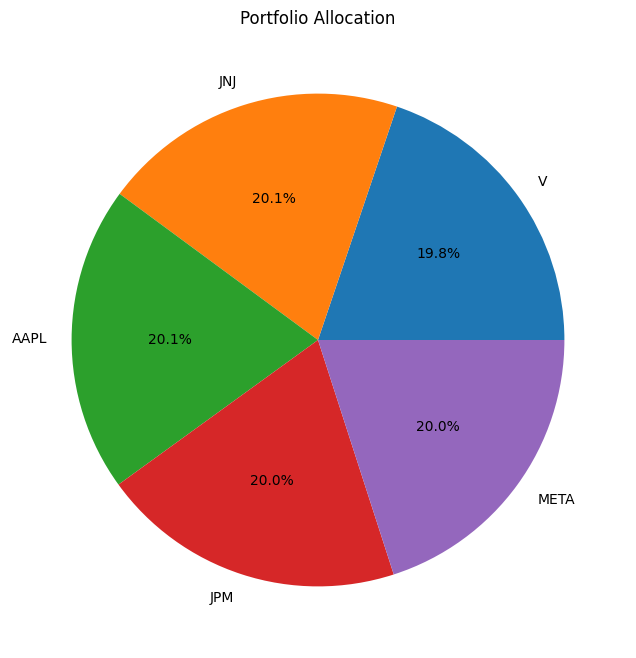

In [89]:
# 15. Data Visualization

# 15.1 Portfolio Allocation
plt.figure(figsize=(8,8))

plt.pie(
    portfolio["Weight"],
    labels=portfolio["Ticker"],
    autopct="%1.1f%%"
)

plt.title("Portfolio Allocation")

plt.show()

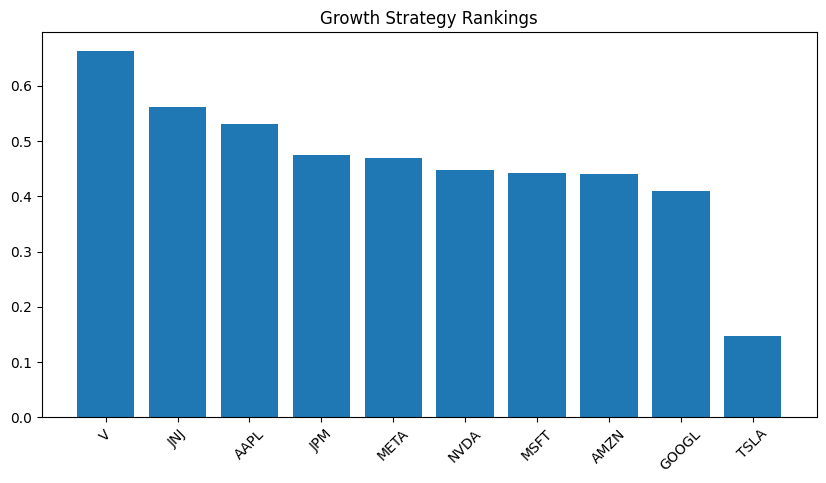

In [90]:
# 15.2 Strategy Score Comparison
plt.figure(figsize=(10,5))

plt.bar(
    growth_rankings["Ticker"],
    growth_rankings["Growth_Score"]
)

plt.title("Growth Strategy Rankings")

plt.xticks(rotation=45)

plt.show()

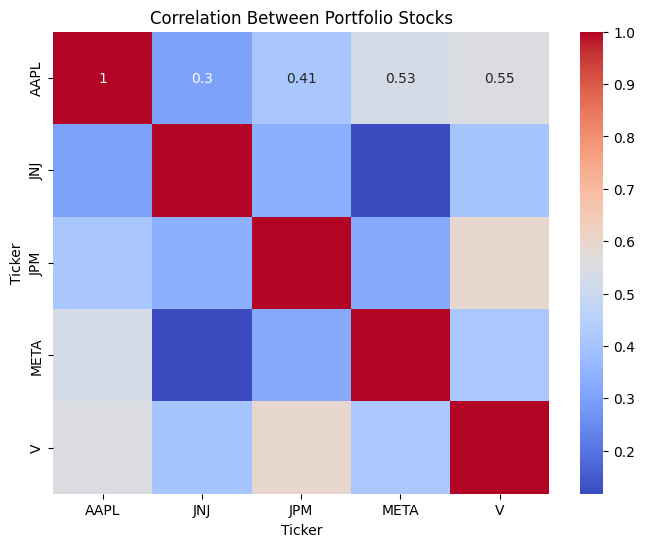

In [91]:
# 15.3 Correlation Heatmap
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    daily_returns.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Portfolio Stocks")

plt.show()

### Correlation Analysis

The heatmap illustrates the correlation among the selected portfolio stocks based on historical daily returns. Most pairwise correlations fall within the moderate range (approximately 0.3–0.6), indicating that the portfolio is reasonably diversified. Lower correlations between certain stocks reduce concentration risk and improve the overall risk-return profile of the portfolio.

In [92]:
# 16.Save Outputs

# 16.2 Save Rankings
growth_rankings.to_csv(
    "Outputs/growth_rankings.csv",
    index=False
)

bluechip_rankings.to_csv(
    "Outputs/bluechip_rankings.csv",
    index=False
)

dividend_rankings.to_csv(
    "Outputs/dividend_rankings.csv",
    index=False
)

In [93]:
# 16.2.Save Porrtfolio

portfolio.to_csv(
    "Outputs/recommended_portfolio.csv",
    index=False
)

In [94]:
# 16.3.Save Performance Metrics

metrics_df.to_csv(
    "Outputs/performance_metrics.csv",
    index=False
)

In [95]:
# 16.4.Save Portfolio Summary

portfolio_summary = portfolio[
    [
        "Ticker",
        "Shares",
        "Weight",
        "Actual_Investment"
    ]
]

portfolio_summary.to_csv(
    "Outputs/portfolio_summary.csv",
    index=False
)

In [96]:
# 16.5. Save Figures

plt.savefig(
    "Outputs/portfolio_vs_benchmark.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [97]:
# 16.6.Check Output Folder

import os

print(os.listdir("Outputs"))

['performance_metrics.csv', 'monte_carlo_simulation.csv', 'efficient_frontier_results.csv', 'bluechip_recommendations.csv', 'bluechip_rankings.csv', 'growth_rankings.csv', 'dividend_rankings.csv', 'growth_recommendations.csv', 'monte_carlo_percentiles.csv', 'portfolio_summary.csv', 'portfolio_vs_benchmark.png', 'recommended_portfolio.csv', 'mpt_optimal_weights.csv', 'dividend_recommendations.csv']


# 17. Project Conclusion

This project developed a Strategy-Aware Portfolio Advisory Platform that assists investors in constructing diversified portfolios using quantitative and sentiment-based analysis.

Historical market data was collected from Yahoo Finance, while analyst sentiment scores were incorporated to improve investment decision-making. Multiple investment strategies, including Growth, Blue Chip, and Dividend investing, were implemented through a weighted scoring framework.

The recommended portfolio was backtested against the S&P 500 benchmark and evaluated using performance metrics such as Annual Return, CAGR, Sharpe Ratio, Annual Volatility, and Maximum Drawdown. The results demonstrate that combining technical indicators with analyst sentiment can provide a systematic and explainable approach to portfolio construction.

Overall, the project showcases an end-to-end data science workflow involving data collection, feature engineering, scoring models, portfolio optimization, performance evaluation, and visualization.

# 18. Future Enhancements

Future improvements to this project include:

- Implement Modern Portfolio Theory (MPT) for portfolio optimization.
- Add Monte Carlo Simulation for future portfolio return forecasting.
- Develop an interactive Streamlit dashboard for user-friendly portfolio analysis.
- Incorporate additional market indicators such as macroeconomic variables.
- Expand investment strategies to include Value Investing, ESG Investing, and Sector Rotation.
- Integrate real-time market data and analyst recommendations through APIs.
- Explore machine learning models to predict future stock returns.

In [98]:
# 19. Modern Portfolio Theory (MPT)

## Objective

Modern Portfolio Theory (MPT), introduced by Harry Markowitz, aims to construct an investment portfolio that maximizes expected return for a given level of risk. Rather than allocating equal amounts to each stock, MPT uses historical returns and covariance between assets to determine the optimal portfolio weights.

In this section, we optimize the portfolio using historical market data and compare the optimized allocation with the equal-weight portfolio developed earlier.

In [99]:
# 19.1. Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [100]:
# 19.2.Portfolio Stock

portfolio["Ticker"]

15929       V
15923     JNJ
15920    AAPL
15924     JPM
15925    META
Name: Ticker, dtype: object

In [101]:
selected_tickers = portfolio["Ticker"].tolist()

selected_tickers

['V', 'JNJ', 'AAPL', 'JPM', 'META']

In [102]:
# 19.4. Download Historical Prices
price_data = yf.download(
    selected_tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True
)["Close"]

price_data.head()

/Users/sneha/anaconda3/lib/python3.11/site-packages/yfinance/scrapers/history.py:389: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
/Users/sneha/anaconda3/lib/python3.11/site-packages/yfinance/scrapers/history.py:389: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
/Users/sneha/anaconda3/lib/python3.11/site-packages/yfinance/scrapers/history.py:389: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
/Users/sneha/anaconda3/lib/python3.11/site-packages/yfinance/scrapers/history.py:389: FutureWarning: The default dtype for empty Series will be 'object

Ticker,AAPL,JNJ,JPM,META,V
Date,,,,,
2020-01-02,72.333870,121.936920,117.899223,207.953842,182.431046
2020-01-03,71.630646,120.525192,116.343346,206.853500,180.980164
2020-01-06,72.201424,120.374840,116.250877,210.749313,180.588776
2020-01-07,71.861847,121.109970,114.274521,211.205276,180.111542
2020-01-08,73.017853,121.093239,115.165955,213.346481,183.194687


In [103]:
# 19.5.Daily Returns

returns_df = price_data.pct_change().dropna()

returns_df.head()

Ticker,AAPL,JNJ,JPM,META,V
Date,,,,,
2020-01-03,-0.009722,-0.011578,-0.013197,-0.005291,-0.007953
2020-01-06,0.007968,-0.001247,-0.000795,0.018834,-0.002163
2020-01-07,-0.004703,0.006107,-0.017001,0.002164,-0.002643
2020-01-08,0.016087,-0.000138,0.007801,0.010138,0.017118
2020-01-09,0.021241,0.002966,0.003651,0.014311,0.006930


In [104]:
# 19.6.Calculate Expected Annual Returns

expected_returns = returns_df.mean() * 252

expected_returns

Ticker
AAPL    0.283871
JNJ     0.129654
JPM     0.211559
META    0.275006
V       0.142607
dtype: float64

In [105]:
# 19.7. Calculate Covariance Matrix

cov_matrix = returns_df.cov() * 252

cov_matrix

Ticker,AAPL,JNJ,JPM,META,V
Ticker,,,,,
AAPL,0.098673,0.018672,0.039683,0.072638,0.046320
JNJ,0.018672,0.038891,0.020592,0.010158,0.021236
JPM,0.039683,0.020592,0.095183,0.043447,0.049318
META,0.072638,0.010158,0.043447,0.191428,0.048715
V,0.046320,0.021236,0.049318,0.048715,0.072227


In [106]:
# 19.8.Portfolio Performance Function

def portfolio_performance(weights, expected_returns, cov_matrix):

    portfolio_return = np.sum(weights * expected_returns)

    portfolio_volatility = np.sqrt(
        np.dot(
            weights.T,
            np.dot(cov_matrix, weights)
        )
    )

    return portfolio_return, portfolio_volatility

In [107]:
# 19.9.Test The Functions

weights = np.repeat(
    1 / len(selected_tickers),
    len(selected_tickers)
)

weights

array([0.2, 0.2, 0.2, 0.2, 0.2])

In [108]:
portfolio_return, portfolio_risk = portfolio_performance(
    weights,
    expected_returns,
    cov_matrix
)

print(f"Expected Return : {portfolio_return:.2%}")
print(f"Portfolio Risk  : {portfolio_risk:.2%}")

Expected Return : 20.85%
Portfolio Risk  : 22.25%


In [109]:
# 19.10.GEnerate random Portfolios

num_portfolios = 10000

results = np.zeros((3, num_portfolios))

weights_record = []

for i in range(num_portfolios):

    weights = np.random.random(len(selected_tickers))
    weights /= np.sum(weights)

    weights_record.append(weights)

    portfolio_return, portfolio_risk = portfolio_performance(
        weights,
        expected_returns,
        cov_matrix
    )

    sharpe = portfolio_return / portfolio_risk

    results[0, i] = portfolio_return
    results[1, i] = portfolio_risk
    results[2, i] = sharpe

In [110]:
# 19.11.Create Results DataFrames

results_df = pd.DataFrame({

    "Return": results[0],
    "Risk": results[1],
    "Sharpe": results[2]

})

results_df.head()

,Return,Risk,Sharpe
0,0.200308,0.236743,0.846102
1,0.208636,0.229547,0.908901
2,0.214261,0.255492,0.838620
3,0.207393,0.239960,0.864281
4,0.216821,0.258959,0.837281


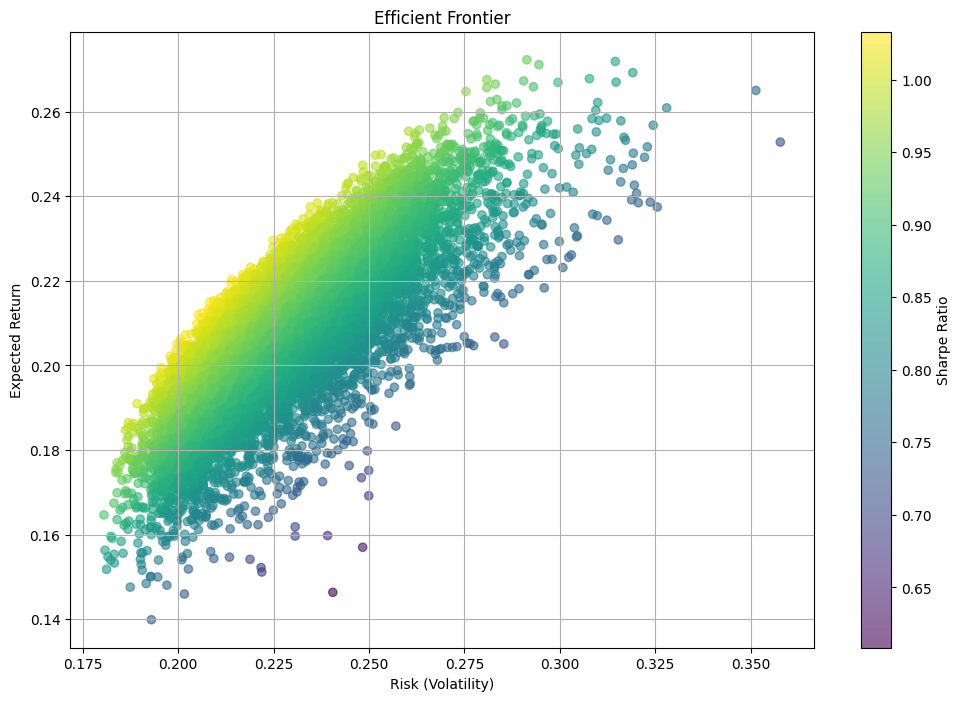

In [111]:
# 19.12.Plot the Efficient Frontier

plt.figure(figsize=(12,8))

scatter = plt.scatter(
    results_df["Risk"],
    results_df["Return"],
    c=results_df["Sharpe"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(scatter, label="Sharpe Ratio")

plt.xlabel("Risk (Volatility)")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier")

plt.grid(True)

plt.show()

In [112]:
# 19.13.Find The Optimal Portfolio

max_sharpe_idx = results_df["Sharpe"].idxmax()

optimal_weights = weights_record[max_sharpe_idx]

optimal_portfolio = pd.DataFrame({

    "Ticker": selected_tickers,
    "Optimal Weight": optimal_weights

})

optimal_portfolio

,Ticker,Optimal Weight
0,V,0.365648
1,JNJ,0.371470
2,AAPL,0.182401
3,JPM,0.075287
4,META,0.005194


In [113]:
# 19.14 Compare Equal Weight and Optimized Portfolio

comparison = pd.DataFrame({
    "Ticker": selected_tickers,
    "Equal Weight": np.repeat(
        1/len(selected_tickers),
        len(selected_tickers)
    ),
    "Optimized Weight": optimal_weights
})

comparison

,Ticker,Equal Weight,Optimized Weight
0,V,0.2,0.365648
1,JNJ,0.2,0.371470
2,AAPL,0.2,0.182401
3,JPM,0.2,0.075287
4,META,0.2,0.005194


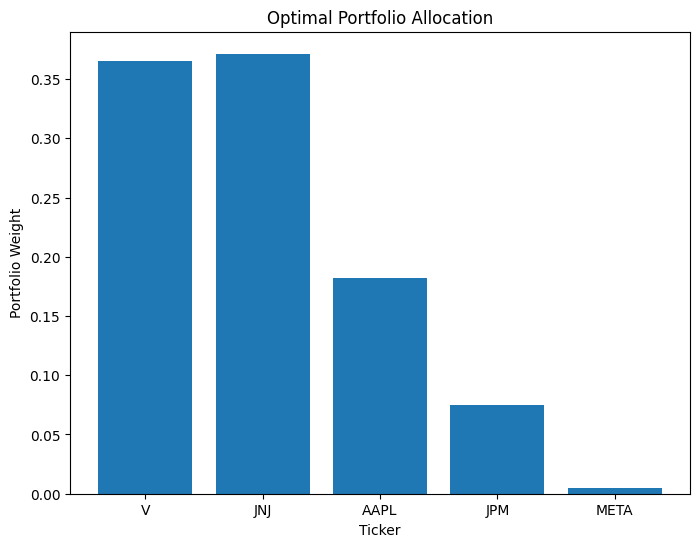

In [114]:
# 19.15.Plot Portfolio Allocation

plt.figure(figsize=(8,6))

plt.bar(
    comparison["Ticker"],
    comparison["Optimized Weight"]
)

plt.title("Optimal Portfolio Allocation")
plt.ylabel("Portfolio Weight")
plt.xlabel("Ticker")

plt.show()

In [115]:
# 19.16.Save Results

comparison.to_csv(
    "Outputs/mpt_optimal_weights.csv",
    index=False
)

results_df.to_csv(
    "Outputs/efficient_frontier_results.csv",
    index=False
)

## Conclusion

Modern Portfolio Theory was applied to optimize the portfolio using historical returns and the covariance matrix. Rather than assigning equal capital to each stock, the optimizer identified the allocation that maximized the Sharpe Ratio.

The results indicate that Visa (V) and Johnson & Johnson (JNJ) received the highest allocations due to their favorable balance between expected return and risk, while Meta (META) received a minimal allocation because of its comparatively weaker risk-adjusted performance during the selected time period.

This demonstrates how quantitative optimization can improve portfolio construction compared with equal-weight investing.

In [116]:
# 20.Monte Carlo Stimulation

## Objective

Monte Carlo Simulation estimates the possible future performance of the optimized portfolio by simulating thousands of potential market paths using historical return and volatility. This provides an understanding of the uncertainty and potential outcomes of an investment rather than relying on a single forecast.

In [117]:
# 20.1.Stimulation Parameters

# Number of simulations

num_simulations = 1000

# Number of trading days (1 year)

num_days = 252

initial_portfolio_value = investment_amount

print(num_simulations)
print(num_days)
print(initial_portfolio_value)

1000
252
100000


In [118]:
# 20.2.Portfolio Daily Returns

portfolio_daily_returns = (
    returns_df @ optimal_weights
)

portfolio_daily_returns.head()

Date
2020-01-03   -0.010702
2020-01-06    0.003712
2020-01-07   -0.002403
2020-01-08    0.008106
2020-01-09    0.010648
dtype: float64

In [119]:
# 20.3.Estimate Mean and Standard Deviation

mu = portfolio_daily_returns.mean()

sigma = portfolio_daily_returns.std()

print("Daily Mean :", mu)

print("Daily Std :", sigma)

Daily Mean : 0.0008412417660414109
Daily Std : 0.012928238287667494


In [120]:
# 20.4.Generate Stimulation

simulation_df = pd.DataFrame()

for i in range(num_simulations):

    prices = [initial_portfolio_value]

    for j in range(num_days):

        daily_return = np.random.normal(
            mu,
            sigma
        )

        prices.append(
            prices[-1] * (1 + daily_return)
        )

    simulation_df[i] = prices

/var/folders/h1/n_brrnn95rbgjntwcswbttnw0000gn/T/ipykernel_59935/3518098205.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  simulation_df[i] = prices
/var/folders/h1/n_brrnn95rbgjntwcswbttnw0000gn/T/ipykernel_59935/3518098205.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  simulation_df[i] = prices
/var/folders/h1/n_brrnn95rbgjntwcswbttnw0000gn/T/ipykernel_59935/3518098205.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performa

/var/folders/h1/n_brrnn95rbgjntwcswbttnw0000gn/T/ipykernel_59935/3518098205.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  simulation_df[i] = prices
/var/folders/h1/n_brrnn95rbgjntwcswbttnw0000gn/T/ipykernel_59935/3518098205.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  simulation_df[i] = prices
/var/folders/h1/n_brrnn95rbgjntwcswbttnw0000gn/T/ipykernel_59935/3518098205.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performa

In [121]:
# 20.5.View Stimulation Data

simulation_df.head()

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
1,99274.753936,100549.352699,99174.294842,102744.880336,99322.213787,99003.452716,101170.029585,99749.956213,99421.087888,98687.430788,...,101539.865516,99733.335422,99669.952734,101125.241278,99109.689726,98687.622847,102148.959792,100209.927693,99697.771143,99999.642081
2,101976.265298,101935.997041,98559.367876,104427.965768,99115.206672,100682.965080,103256.776458,99772.745485,97931.974037,98564.289957,...,101771.489096,101692.894855,98608.107426,101314.884080,99278.135108,97907.389601,104586.945813,101022.839988,98857.526537,100870.661425
3,104393.898782,101330.971250,100448.892823,104019.056254,98996.446871,102990.363226,103557.133330,99160.039671,99009.779857,98107.782461,...,102550.193516,100168.200141,98500.705085,101511.036641,99664.826011,99565.048269,104218.305565,102949.429727,96693.154825,102643.041478
4,104898.007981,101546.603424,100265.111474,106246.227645,99031.370380,104414.235623,103955.890928,98955.740286,100036.304480,99661.601670,...,103643.768152,100216.298213,97843.330979,103291.040333,98511.508697,98580.348905,103302.729626,102782.742342,98074.606822,103211.241990


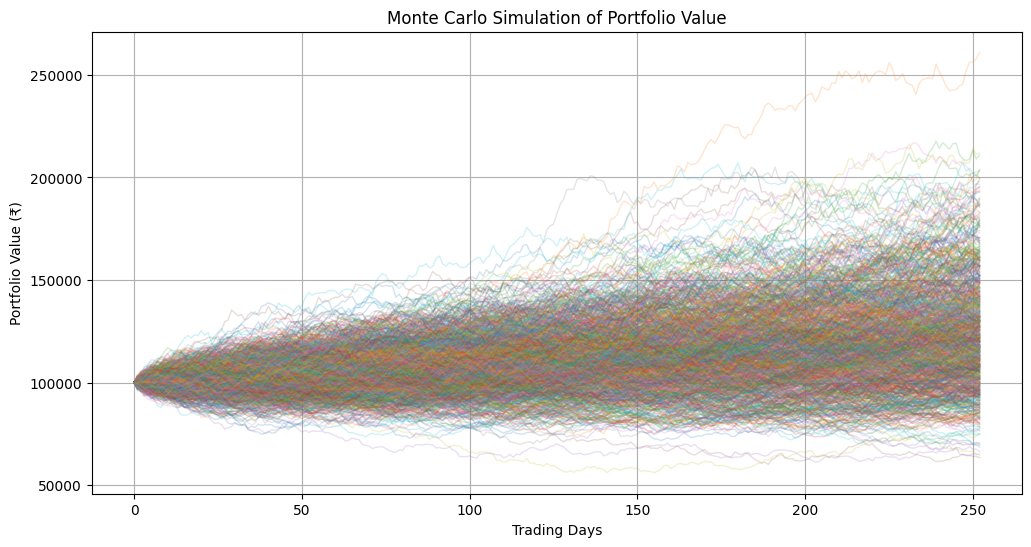

In [122]:
# 20.6.Plot Monte Carlo Stimulation

plt.figure(figsize=(12,6))

plt.plot(
    simulation_df,
    linewidth=1,
    alpha=0.2
)

plt.title("Monte Carlo Simulation of Portfolio Value")

plt.xlabel("Trading Days")

plt.ylabel("Portfolio Value (₹)")

plt.grid(True)

plt.show()

In [123]:
# 20.7.Distribution of Final Portfolio Values

final_values = simulation_df.iloc[-1]

final_values.describe()

count      1000.000000
mean     123631.143678
std       26059.041273
min       63495.812502
25%      105342.265099
50%      120250.541117
75%      139274.747489
max      260788.382021
Name: 252, dtype: float64

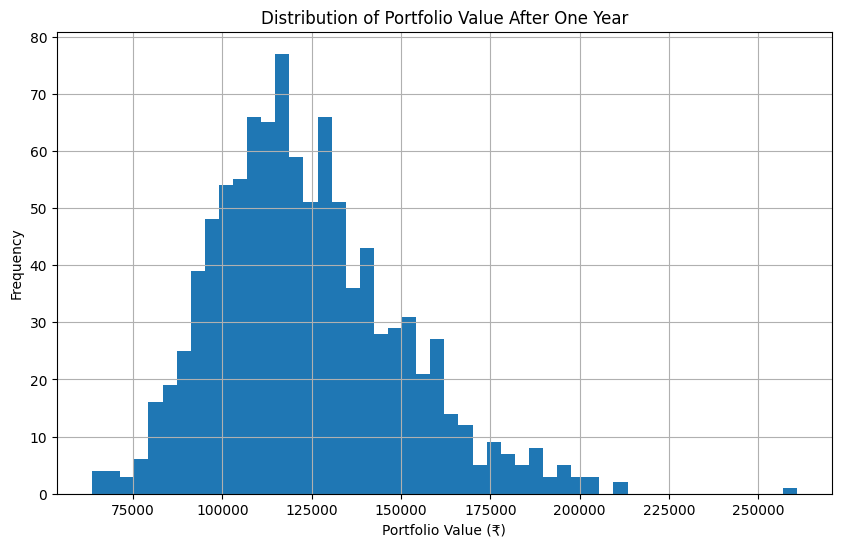

In [124]:
# 20.8.Plot Distribution

plt.figure(figsize=(10,6))

plt.hist(
    final_values,
    bins=50
)

plt.title("Distribution of Portfolio Value After One Year")

plt.xlabel("Portfolio Value (₹)")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

In [125]:
# 20.9.Calculate Percentile

percentiles = pd.DataFrame({

    "Percentile":[
        "5%",
        "50%",
        "95%"
    ],

    "Portfolio Value":[

        np.percentile(final_values,5),

        np.percentile(final_values,50),

        np.percentile(final_values,95)

    ]

})

percentiles

,Percentile,Portfolio Value
0,5%,86802.311659
1,50%,120250.541117
2,95%,170470.178759


In [126]:
# 20.10.Probability Of Profit

prob_profit = (

    final_values > initial_portfolio_value

).mean()

print(

    f"Probability of Profit: {prob_profit:.2%}"

)

Probability of Profit: 82.40%


In [127]:
# 20.12. Value at Risk 

VaR95 = initial_portfolio_value - np.percentile(
    final_values,
    5
)

print(

    f"95% Value at Risk: ₹{VaR95:,.2f}"

)

95% Value at Risk: ₹13,197.69


In [128]:
# 20.13.Consitional Value at Risk

CVaR95 = (

    initial_portfolio_value -

    final_values[
        final_values <= np.percentile(final_values,5)
    ].mean()

)

print(

    f"95% Conditional Value at Risk: ₹{CVaR95:,.2f}"

)

95% Conditional Value at Risk: ₹20,125.83


In [129]:
# 20.14.Save Results

percentiles.to_csv(
    "Outputs/monte_carlo_percentiles.csv",
    index=False
)

simulation_df.to_csv(
    "Outputs/monte_carlo_simulation.csv",
    index=False
)

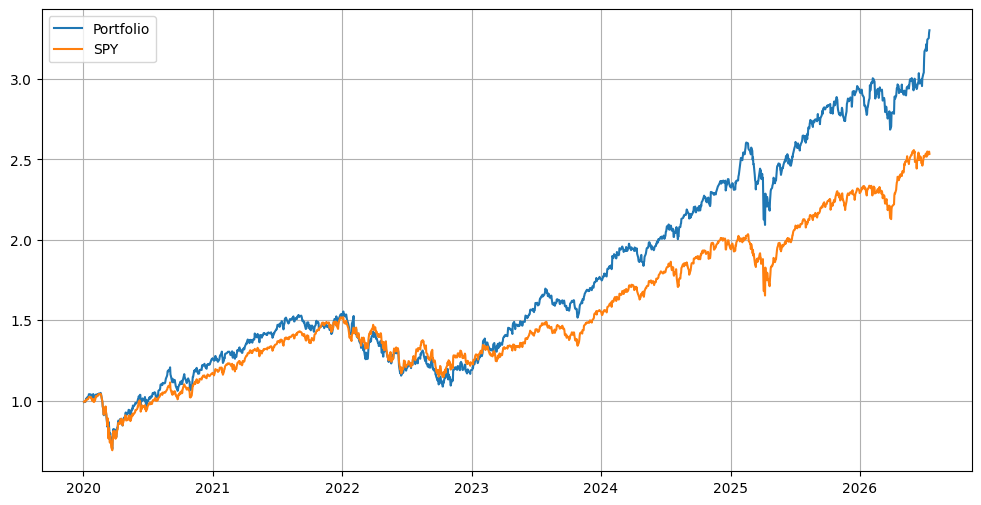

In [130]:
plt.figure(figsize=(12,6))

plt.plot(portfolio_growth, label="Portfolio")
plt.plot(benchmark_growth, label="SPY")

plt.legend()
plt.grid(True)

plt.savefig(
    "Outputs/portfolio_vs_benchmark.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [131]:
pip install streamlit


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [132]:
import streamlit as st
import pandas as pd

In [133]:
st.set_page_config(
    page_title="Strategy-Aware Portfolio Advisory",
    page_icon="📈",
    layout="wide"
)

st.title("📈 Strategy-Aware Portfolio Advisory Platform")

st.write(
    """
    This application recommends stocks based on the selected
    investment strategy and investment amount.
    """
)

2026-07-17 12:53:15.289 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.290 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.522 
  command:

    streamlit run /Users/sneha/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-07-17 12:53:15.522 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.523 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.523 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.523 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored 

In [134]:
st.set_page_config(
    page_title="Strategy-Aware Portfolio Advisory",
    page_icon="📈",
    layout="wide"
)

st.title("📈 Strategy-Aware Portfolio Advisory Platform")

st.write(
    """
    This application recommends stocks based on the selected
    investment strategy and investment amount.
    """
)

2026-07-17 12:53:15.531 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.533 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.533 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.534 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.535 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.535 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.535 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [135]:
growth = pd.read_csv("../Outputs/growth_rankings.csv")

bluechip = pd.read_csv("../Outputs/bluechip_rankings.csv")

dividend = pd.read_csv("../Outputs/dividend_rankings.csv")

In [136]:
strategy = st.selectbox(
    "Choose Investment Strategy",
    [
        "Growth",
        "Blue Chip",
        "Dividend"
    ]
)

investment = st.number_input(
    "Investment Amount (₹)",
    min_value=10000,
    value=100000,
    step=10000
)

2026-07-17 12:53:15.554 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.555 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.555 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.556 Session state does not function when running a script without `streamlit run`
2026-07-17 12:53:15.556 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.556 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.557 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.557 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53

In [137]:
st.subheader("Top Recommendations")

st.dataframe(
    recommendations.head(5)
)

2026-07-17 12:53:15.563 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.563 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.564 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.580 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.581 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.581 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.581 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [138]:
st.subheader("🏆 Best Recommendation")

top = recommendations.iloc[0]

st.metric(
    "Ticker",
    top["Ticker"]
)

st.write(top)

2026-07-17 12:53:15.586 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.587 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.587 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.588 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.588 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.589 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.590 Serialization of dataframe to Arrow table was unsuccessful. Applying automatic fixes for column types to make the dataframe Arrow-compatible.
Traceback (most recent call last):
  File "/Users/sneha/anaconda3/lib/python3.

In [139]:
weight = 1 / len(recommendations.head(5))

portfolio = recommendations.head(5).copy()

portfolio["Weight"] = weight

portfolio["Investment"] = investment * portfolio["Weight"]

st.subheader("Suggested Portfolio")

st.dataframe(portfolio)

2026-07-17 12:53:15.599 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.599 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.599 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.601 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.601 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.601 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.602 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [140]:
metrics = pd.read_csv("../Outputs/performance_metrics.csv")

st.subheader("Portfolio Metrics")

st.dataframe(metrics)

2026-07-17 12:53:15.608 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.608 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.609 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.609 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.609 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.610 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.610 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [141]:
st.subheader("Portfolio Performance")

st.image("../Outputs/portfolio_vs_benchmark.png")

2026-07-17 12:53:15.614 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.615 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.615 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.616 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.765 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.766 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 12:53:15.766 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [142]:
ls

Data/      Notebooks/ Outputs/   src/


In [143]:
cd src/

/Users/sneha/Strategy-Aware Portfolio Advisory /src


In [144]:
cd ..

/Users/sneha/Strategy-Aware Portfolio Advisory 


In [145]:
streamlit run src/app.py

SyntaxError: invalid syntax (832789308.py, line 1)

In [ ]:
cd Strategy-Aware Portfolio Advisory /

In [ ]:
cd src/

In [ ]:
cd ..

In [ ]:
streamlit run src/app.py

In [ ]:
ls src

In [ ]:
streamlit run app.py

In [ ]:
stock_data = load_stock_data()

st.write(stock_data.columns.tolist())